# WMO National Renewable Atlases – Demonstration for Policy Makers

This notebook is a **demonstration** of the workflow used to generate the National Renewable Atlas products.

The figures displayed in this notebook are **not final Atlas products**. They are illustrative PNG outputs prepared to explain, step by step, the methodological upgrades provided by the workflow, from global datasets to country-specific Atlas-ready information.

For clarity, one representative country and one representative variable have been selected for each Atlas type. When the user selects `ATLAS_DEMO`, the notebook automatically adapts the following steps and loads the corresponding demonstration figures.

Dataset-opening and processing commands are intentionally retained as **commented code**. This makes the data sources and processing chain transparent, while keeping the demo fast and robust for policy-maker presentations.

## How to run the demonstration

1. Select the Atlas type by setting `ATLAS_DEMO`.
2. Run the notebook from top to bottom.
3. The active cells load pre-generated PNG figures.
4. Commented cells show which datasets would be opened or processed in the full production workflow.
5. The notebook is organised into **Pilot Countries**, **Present Climate**, and **Future Climate** sections.

#### Python packages to import

In [1]:
import matplotlib.pyplot as plt
import rioxarray
from pyhdf.SD import SD, SDC
import xarray as xr
import pandas as pd
import glob
import os
import geopandas as gpd
import numpy as np
from shapely.ops import cascaded_union
from shapely.ops import unary_union
from datetime import datetime
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

## Pilot Countries

### Countries included in this demonstration phase

This first step gives a geographical overview of the pilot countries included in the current phase of the National Renewable Atlas initiative.

The map is loaded as a pre-generated PNG for presentation purposes. The commented code shows how the figure can be recreated from the country shapefile.

/tmp/ipykernel_638055/1386420424.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


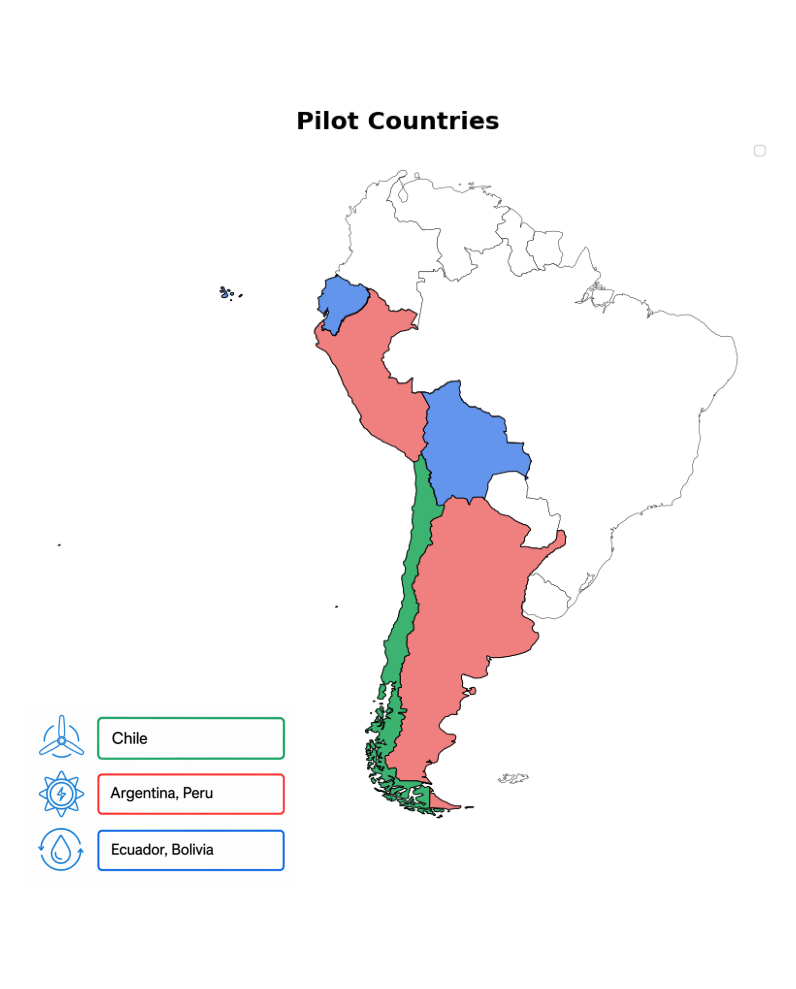

In [2]:
#shapefile_path = './world_map/ne_50m_admin_0_countries.shp'
#world = gpd.read_file(shapefile_path)
#south_america = world[world["CONTINENT"] == "South America"].copy()

#pilot_colors = {"Peru": "lightcoral", "Argentina": "lightcoral","Chile": "mediumseagreen","Ecuador": "cornflowerblue","Bolivia": "cornflowerblue"}

#fig, ax = plt.subplots(figsize=(8, 10))
#south_america.plot(ax=ax,color="white",edgecolor="black",linewidth=0.3)
#for country, color, label in zip(list(pilot_colors.keys()),list(pilot_colors.values()),list(pilot_colors.keys())):
#    south_america[south_america["SOVEREIGNT"] == country].plot(ax=ax,label= label,color=color,edgecolor="black", linewidth=0.7)
#ax.legend()
#ax.set_title("Pilot Countries", fontsize=18, fontweight="bold")
#ax.set_axis_off()
#plt.tight_layout()
#plt.savefig('./figures/DEMO/pilot_countries.png')

### Integrate the Cartopy Map with the Image that Shows the type of renewable per country (Map with Legend)
pilot_img = mpimg.imread("./figures/DEMO/pilot_countries.png")
atlas_img = mpimg.imread("./figures/DEMO/atlases_countries.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(pilot_img)
ax.axis("off")
axins = inset_axes(ax,width="35%",      height="35%",     loc="lower left", borderpad=1)
axins.imshow(atlas_img)
axins.axis("off")
for spine in axins.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.show()

## Functions involved in the creation of the PNG files

In [3]:
def roll_xdf(ds, lon_name="longitude"):
    """Converts Longitude from 0-360°E to -180°W -180°E"""
    ds = ds.assign_coords({
        lon_name: ((ds[lon_name] + 180) % 360) - 180
    })
    return ds.sortby(lon_name)
    
def get_geometries(cut_on, shapefile=None):
    """
    Retrieve geometries for a given region or bounding box coordinates.
    """
    if cut_on == "europe":
        geometries = gpd.GeoSeries.from_bbox((-25, 32, 48.5, 75))
    elif cut_on == "SADC":
        geometries = gpd.GeoSeries.from_bbox((2, -37, 60, 7))
    elif isinstance(cut_on, list):
        # Expected format: [lon_min, lat_min, lon_max, lat_max]
        geometries = gpd.GeoSeries.from_bbox(tuple(cut_on))
    else:
        if shapefile is None:
            geometries = get_boundaries(cut_on.capitalize(), continent=False)
        else:
            gdf = gpd.read_file(shapefile)
            geometries = gdf[gdf["NAME_EN"] == cut_on].geometry

    return geometries

def get_boundaries(name, continent=False):
    world_path = '../world_map/'
    world = gpd.read_file(world_path)

    # Reproject to EPSG:4326
    if world.crs is None:
        world = world.set_crs(epsg=4326)
    else:
        world = world.to_crs(epsg=4326)

    if continent:
        world = world.query('REGION_UN == @name')
        boundary = gpd.GeoSeries([world.union_all()], crs='EPSG:4326')
    elif name in world['NAME_EN'].values:
        region_mask = world[world['NAME_EN'] == name]
        boundary = gpd.GeoSeries([region_mask.union_all()], crs='EPSG:4326')
    else:
        raise ValueError(f"{name} not found in shapefile")

    return boundary

In [4]:
def plot_xarray_with_shp(
    da,
    shp,
    cmap,
    vmin=None,
    vmax=None,
    stations=False,
    title=None,
    cbar_label=None,
    output_path=None,
    figsize=(15, 7),
    title_fontsize=18,
    label_fontsize=14,
    tick_fontsize=12,
    cbar_label_fontsize=14,
    cbar_tick_fontsize=12,
    shp_edgecolor="black",
    shp_linewidth=1,
    limits = False,
    xlim = None,
    ylim = None
):
    try:
        da = da.rio.set_spatial_dims(
            x_dim="longitude",
            y_dim="latitude",
            inplace=False
        )
        da = da.rio.write_crs("epsg:4326", inplace=False)
    except Exception:
        pass

    fig, ax = plt.subplots(figsize=figsize)

    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={
            "label": cbar_label if cbar_label is not None else ""
        }
    )

    shp.plot(
        ax=ax,
        edgecolor=shp_edgecolor,
        facecolor="none",
        linewidth=shp_linewidth
    )

    if stations:
        if country == "peru":
            ax.scatter(stats.lon, stats.lat)
        elif country == "chile":
            ax.scatter(stats.longitude, stats.latitude)

    ax.set_xlabel("Longitude", fontsize=label_fontsize)
    ax.set_ylabel("Latitude", fontsize=label_fontsize)
    if limits == True:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize)

    if im.colorbar is not None:
        im.colorbar.ax.yaxis.label.set_size(cbar_label_fontsize)
        im.colorbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    try:
        print(da.rio.crs)
    except Exception:
        print("CRS non disponibile")

In [5]:
def plot_geometries_with_shp(
    gdf,
    shp=None,
    title=None,
    output_path=None,
    figsize=(10, 8),
    facecolor="steelblue",
    edgecolor="black",
    linewidth=0.3,
    shp_edgecolor="black",
    shp_linewidth=1.0,
    shp_facecolor="none",
    title_fontsize=18,
    label_fontsize=14,
    tick_fontsize=12,
    limits=False,
    xlim=None,
    ylim=None,
    show_axis=True,
    dpi=300,
    stations=False
):
    fig, ax = plt.subplots(figsize=figsize)

    gdf.plot(
        ax=ax,
        color=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth
    )

    if shp is not None:
        shp.plot(
            ax=ax,
            edgecolor=shp_edgecolor,
            facecolor=shp_facecolor,
            linewidth=shp_linewidth
        )

    ax.set_xlabel("Longitude", fontsize=label_fontsize)
    ax.set_ylabel("Latitude", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    if limits:
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, fontweight="bold")

    if not show_axis:
        ax.set_axis_off()

    ax.set_aspect("equal")

    if stations:
        ax.scatter(stats.longitude.drop_duplicates(), stats.latitude.drop_duplicates(),color='r')

    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    plt.show()

In [6]:
def plot_geometries_by_column(
    gdf,
    column="mean_river_discharge",
    shp=None,
    title=None,
    cbar_label=None,
    output_path=None,
    figsize=(10, 8),
    cmap="viridis",
    log_scale=True,
    log_vmin=1,
    log_vmax=5000,
    cbar_ticks=None,
    basin_boundary_color="black",
    basin_boundary_linewidth=0.3,
    outer_boundary_color="black",
    outer_boundary_linewidth=1.5,
    shp_edgecolor="black",
    shp_linewidth=1.0,
    title_fontsize=18,
    label_fontsize=14,
    tick_fontsize=12,
    cbar_label_fontsize=14,
    cbar_tick_fontsize=12,
    limits=False,
    xlim=None,
    ylim=None,
    show_axis=True,
    dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm, Normalize
    from matplotlib.cm import ScalarMappable

    gdf_plot = gdf.copy(deep=True)
    gdf_plot[column] = gdf_plot[column].astype(float)

    if log_scale:
        gdf_plot[column] = gdf_plot[column].clip(lower=log_vmin, upper=log_vmax)
        norm = LogNorm(vmin=log_vmin, vmax=log_vmax)

        if cbar_ticks is None:
            cbar_ticks = [1, 10, 100, 1000, 5000]

        sm_values = np.array([log_vmin, log_vmax], dtype=float)

    else:
        vmin = gdf_plot[column].min()
        vmax = gdf_plot[column].max()

        norm = Normalize(vmin=vmin, vmax=vmax)
        cbar_ticks = None

        sm_values = np.array([vmin, vmax], dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    gdf_plot.plot(
        ax=ax,
        column=column,
        cmap=cmap,
        norm=norm,
        edgecolor="none",
        linewidth=0
    )

    gdf_plot.boundary.plot(
        ax=ax,
        color=basin_boundary_color,
        linewidth=basin_boundary_linewidth,
        zorder=20
    )

    gdf_plot.dissolve().boundary.plot(
        ax=ax,
        color=outer_boundary_color,
        linewidth=outer_boundary_linewidth,
        zorder=30
    )

    if shp is not None:
        shp.plot(
            ax=ax,
            edgecolor=shp_edgecolor,
            facecolor="none",
            linewidth=shp_linewidth,
            zorder=40
        )

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(sm_values)

    cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
    cbar.set_label(
        cbar_label if cbar_label is not None else column,
        fontsize=cbar_label_fontsize
    )
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels([str(t) for t in cbar_ticks])

    ax.set_xlabel("Longitude", fontsize=label_fontsize)
    ax.set_ylabel("Latitude", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    if limits:
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, fontweight="bold")

    if not show_axis:
        ax.set_axis_off()

    ax.set_aspect("equal")
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")

    plt.show()

## Select the Atlas demonstration
- solar
- wind
- hydropower

In [7]:
ATLAS_DEMO = 'solar'

In [8]:
print("=" * 70)
print("WMO National Renewable Atlas demonstration")
print("=" * 70)
print(f"Selected Atlas demonstration: {ATLAS_DEMO.upper()}")
print("The workflow will automatically load the corresponding PNG figures.")
print("Commented cells show the datasets used in the full production workflow.")
print("=" * 70)

WMO National Renewable Atlas demonstration
Selected Atlas demonstration: SOLAR
The workflow will automatically load the corresponding PNG figures.
Commented cells show the datasets used in the full production workflow.


In [9]:
if ATLAS_DEMO == 'hydropower':
    country = 'ecuador'
    EXAMPLE_VAR = 'river_discharge'
    CMIP6_VAR = 'rivo'
    VAR = 'dis24'
    cmap = 'YlGnBu'
    unit_cds = 'm3/s'
    unit_cmip = 'm3/s'
    unit_final = 'm3/s'
    
elif ATLAS_DEMO =='wind':
    country = 'chile'
    EXAMPLE_VAR = '10m_u_component_of_wind'
    VAR = 'u10'
    CMIP6_VAR = '10m_u_component_of_wind'
    cmap = 'PiYG'
    unit_cds = "m/s"
    unit_cmip = 'm/s'
    unit_final = 'm/s'
    
else:
    country = 'peru'
    EXAMPLE_VAR = 'surface_solar_radiation_downwards'
    VAR = 'ssrd'
    cmap = 'Reds'
    unit_cds = 'J/m2'
    unit_final = 'kWh/m2/day'
    unit_cmip = 'W/m2'

shapefile_path = './world_map/ne_50m_admin_0_countries.shp'
# Step 0: Retrieve Geometry and Variable datasets
geometries = get_geometries(f'{country.capitalize()}', shapefile_path)

ERROR 1: PROJ: proj_create_from_database: Open of /home/alessandrom/anaconda3/envs/bias_correction_conda/share/proj failed


## Present Climate

In [10]:
print("\nPRESENT CLIMATE")
print("This section shows how observational and reanalysis products are progressively refined into Atlas-ready present-climate layers.")


PRESENT CLIMATE
This section shows how observational and reanalysis products are progressively refined into Atlas-ready present-climate layers.


### Download

#### Copernicus Climate Data Store
- ERA5Land: 9km,  hourly, 1991-2020 climatology
- ERA5:     31km, hourly, 1991-2020 climatology
- GloFAS:   5.5 km, daily, 1991-2020 climatology 

##### ERA5
- Surface Solar Radiation Downwards
- 2m Temperature
- Total Cloud Cover

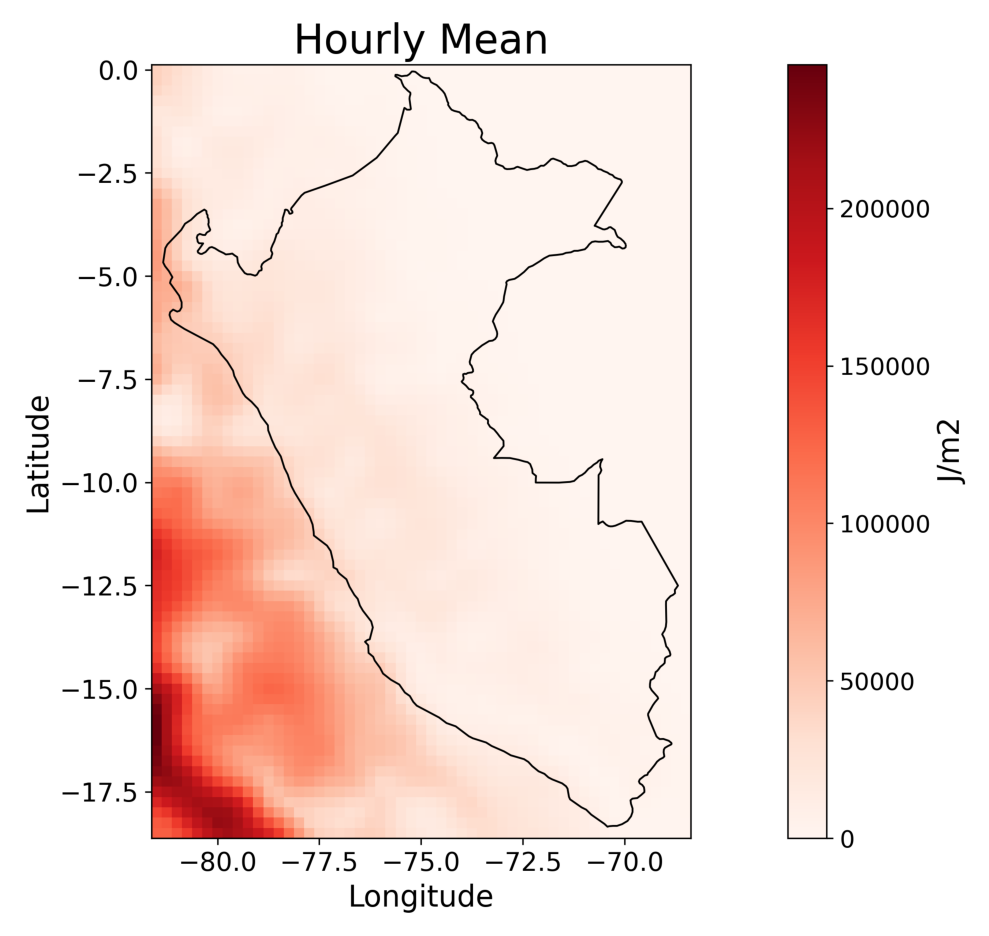

In [11]:
#era5_data = roll_xdf(xr.open_mfdataset(f'./data/cds_downloads/era5/{EXAMPLE_VAR}/{country}/era5_*.nc'),'longitude')
#plot_xarray_with_shp(da=era5_data[f'{VAR}'][0,:,:],shp=geometries,cmap=cmap,title="Hourly Mean",cbar_label=unit_cds,
#    output_path=f"./figures/DEMO/{ATLAS_DEMO}/era5_{ATLAS_DEMO}.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,
#    cbar_label_fontsize=16,cbar_tick_fontsize=13,limits=True,xlim =[-106,-68],ylim =[-56,-18])
try:
    ERA5_raw = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/era5_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(ERA5_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
except:
    print('No ERA5 data sets are involved in this NRA')

##### ERA5Land
All atlases:
- Orography
- Aspect \
\
Solar Atlas:
- Surface Solar Radiation Downwards \
\
Wind Atlas:
- 10m u component of wind
- 10m v component of wind

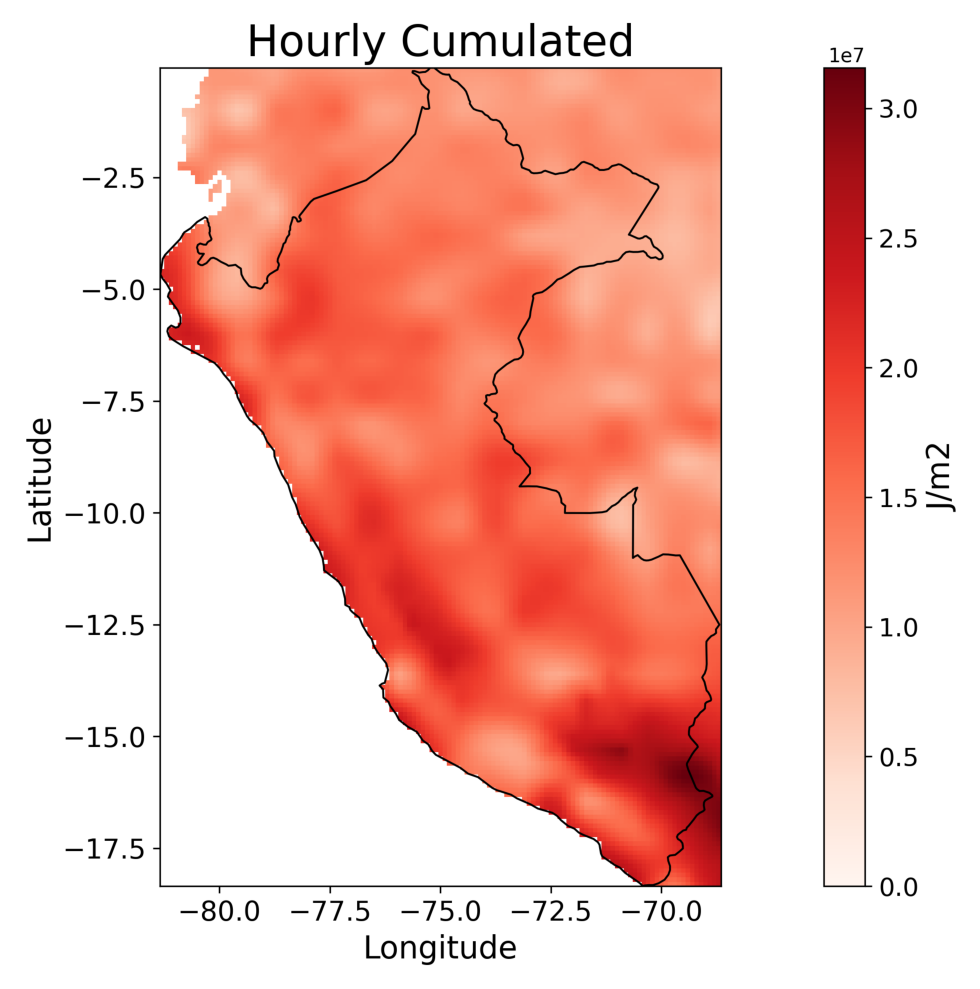

In [12]:
try:
    #era5land_data = roll_xdf(xr.open_mfdataset(f'./data/cds_downloads/era5land/{EXAMPLE_VAR}/{country}/era5land_*.nc'),'longitude')
    #plot_xarray_with_shp(da=era5land_wind[VAR][0,:,:],shp=geometries,cmap=cmap,title="Hourly Mean",cbar_label=unit_cds,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/era5land_{ATLAS_DEMO}.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,
    #    cbar_label_fontsize=16,cbar_tick_fontsize=13,limits=True,xlim =[-106,-68],ylim =[-56,-18])
    
    ERA5Land_raw = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/era5land_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(ERA5Land_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
except:
    print('No ERA5 data sets are involved in this NRA')

##### GloFAS
Hydropower atlases:
- River Discharge

In [13]:
try:
    #GloFAS = xr.open_mfdataset(f'./data/glofas_downloads/{country}/{EXAMPLE_VAR}_*.grib')
    #plot_xarray_with_shp(
    #    da=GloFAS[VAR][0,:,:],shp=geometries,cmap=cmap,vmin=0,vmax=4000,title="Daily Mean",cbar_label=unit_cds,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/glofas_raw.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13)
    GloFAS_raw = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/glofas_raw.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(GloFAS_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
except:
    print('No GloFAS data sets are involved in this NRA')

No GloFAS data sets are involved in this NRA


#### Other Sources
- CERES - EarthAccess: 100km, monthly, 2000-present time series, global
- ECC - IRI database: 1991-2020 Climatology Maps, 2.5°x2.5° resolution

##### IRI
- u and v climatologies

In [14]:
if ATLAS_DEMO == 'wind':
    #iri_data = xr.open_dataset(f'./data/processed/u_clim/u_iri_processed_global.nc')
    #plot_xarray_with_shp(
    #    da=iri_data.u[0,:,:],shp=geometries,cmap="PiYG",title="30-yr Monthly Average",cbar_label="m/s",output_path=f"./figures/DEMO/{ATLAS_DATA}/iri_{ATLAS_DATA}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,limits=True,xlim =[-106,-68],ylim =[-56,-18])
    IRI_raw = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/iri_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(IRI_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No IRI climatology data set are involved in this NRA')

No IRI climatology data set are involved in this NRA


##### CERES
- Global Horizontal Irradiacne

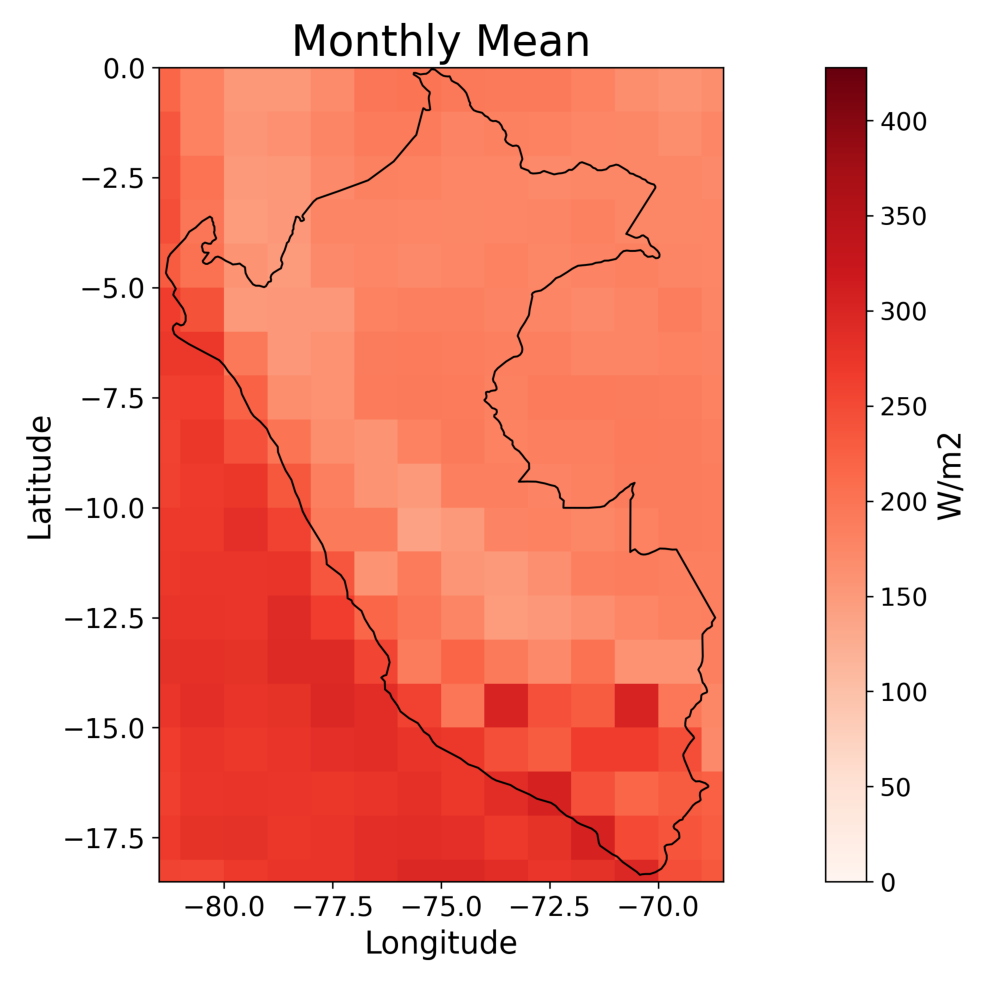

In [15]:
if ATLAS_DEMO =='solar':
    #ceres_data = xr.open_mfdataset(f'./data/processed/ghi/{country}/ghi_*.nc')
    #plot_xarray_with_shp(
    #    da=ceres_data.ghi[0,:,:],shp=geometries,cmap="Reds",vmin=0,title="Monthly Mean",cbar_label="W/m2",
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/ceres_{ATLAS_DEMO}.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,
    #    cbar_label_fontsize=16,cbar_tick_fontsize=13,limits=True,xlim = [-81.5,-68.5],ylim = [-18.5,0])
    CERES_raw = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/ceres_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(CERES_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No CERES Satellite data set are involved in this NRA')

### Pre-processing

- Complete the ERA5Land dataset of SSRD with the interpolated ERA5 variable
- Daily resample & uniforming units of measurement
- Fix coordinates

- Clip on Peru bounding Box (CERES)

#### Solar and Wind: target variable on merged ERA5Land and ERA5 grid

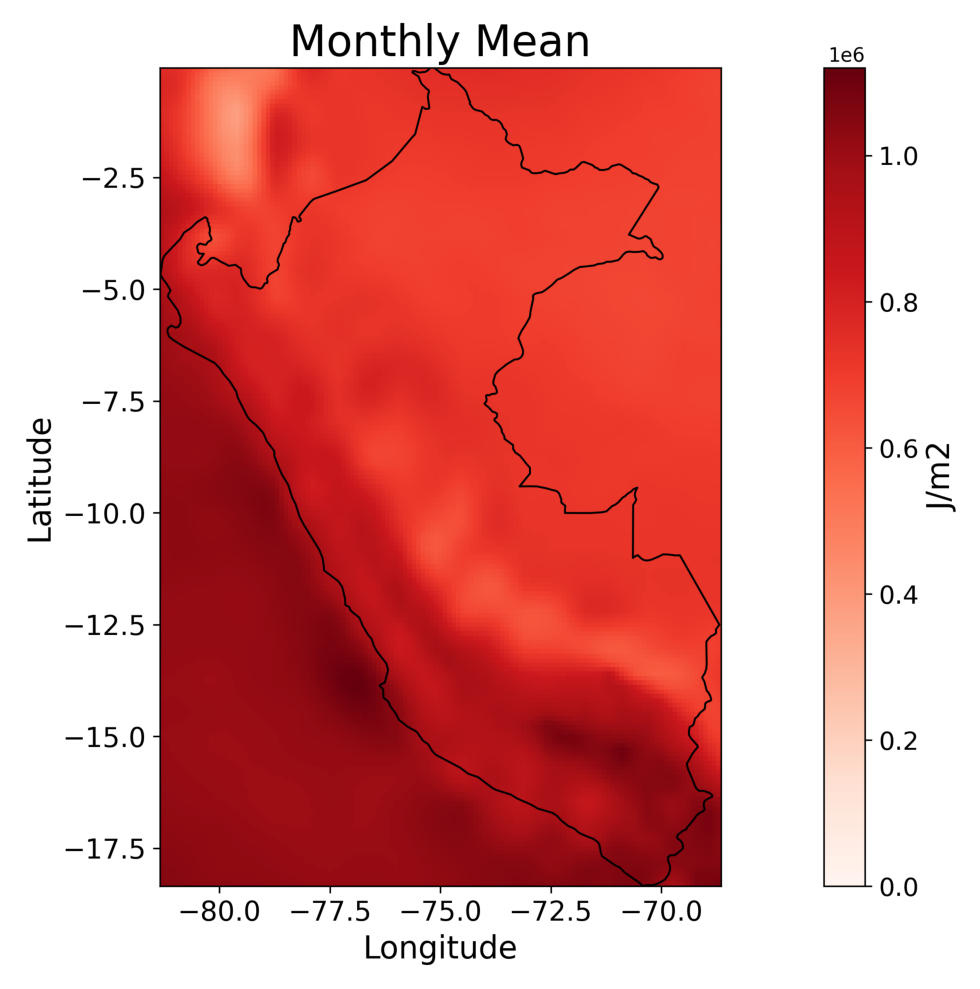

In [16]:
try:
    #preprocess_data = xr.open_mfdataset(f'./data/processed/{EXAMPLE_VAR}/{country}/*_processed.nc')
    #plot_xarray_with_shp(
    #    da=preprocess_data[VAR].groupby('time.month').mean()[0,:,:],shp=geometries,cmap=cmap,title="Monthly Mean",cbar_label=unit,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/preprocess_{ATLAS_DEMO}.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,)
    REAN_pp = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/preprocess_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(REAN_pp)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
except:
    print('In this NRA there is no merging between ERA5 and ERA5Land data sets')

#### Hydropower: river discharge dataset defined only over land

In [17]:
if ATLAS_DEMO == 'hydropower':
    #processed_data = xr.open_mfdataset(f'/mnt/DATA/PROGETTI/27_WMO_ATLAS/{EXAMPLE_VAR}/{country}/*.nc')
    #plot_xarray_with_shp(
    #    da=processed_data[VAR][0,:,:],shp=geometries,cmap=cmap,vmin=0,vmax=4000,title="Daily Mean",cbar_label=unit_cds,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/preprocess_{ATLAS_DEMO}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13)
    REAN_pp = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/preprocess_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(REAN_pp)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Downscaling

#### Solar and Wind: High-Resolution Grid
- Training on ERA5Land grid
- Predict on 90m grid
- GLO90 orography and aspect + other features interpolated on the final grid
- MLP algorithm
- Monthly basis (climatology)

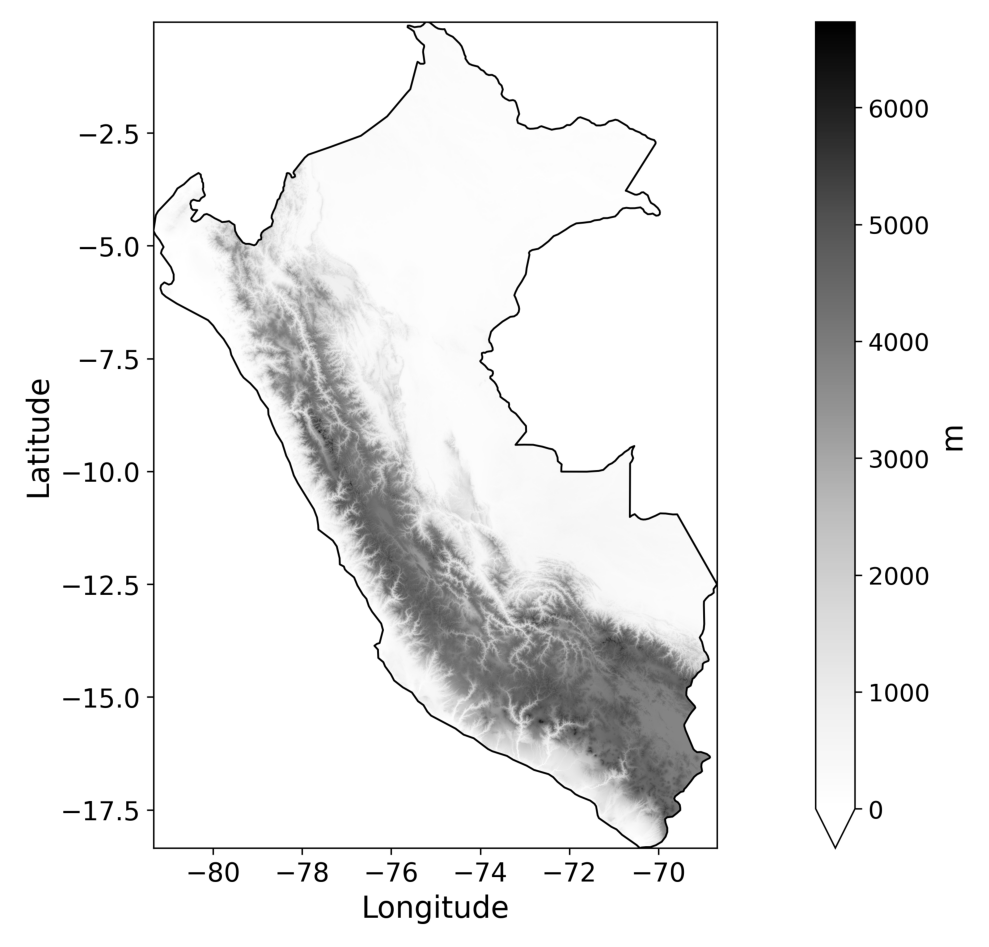

In [18]:
if ATLAS_DEMO == 'wind':
    #glo90_orography = xr.open_dataset('./DEMdata/chile/glo90_orography_chile_continental.nc')
    #plot_xarray_with_shp(
    #    da=glo90_orography.z,shp=geometries,cmap="Greys",title="",cbar_label="m",output_path="./figures/DEMO/wind/orography_glo90.png",
    #    title_fontsize=22,label_fontsize=16, tick_fontsize=14, cbar_label_fontsize=16, cbar_tick_fontsize=13,)
    OROG_glo90 = mpimg.imread("./figures/DEMO/wind/orography_glo90.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(OROG_glo90)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
elif ATLAS_DEMO == 'solar':
    #glo90_orography = xr.open_dataset('/mnt/DATA/PROGETTI/27_WMO_ATLAS/DEMData/peru/glo90_orography_peru.nc')
    #plot_xarray_with_shp(
    #    da=glo90_orography.z,shp=geometries,cmap="Greys",vmin=0,title="",cbar_label="m",output_path="./figures/DEMO/solar/orography_glo90.png",
    #    title_fontsize=22,label_fontsize=16, tick_fontsize=14, cbar_label_fontsize=16, cbar_tick_fontsize=13,)
    OROG_glo90 = mpimg.imread("./figures/DEMO/solar/orography_glo90.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(OROG_glo90)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No GLO-90m high-resolution DEM data are involved in this NRA')

#### Hydropower
- Retrieve HydroSHEDS Products
- Aggregate river discharge on catchments geometry
- Compute the average
- Plot along with the rivers shape

##### HydroSHEDS Database: HydroBASINS
- Aggregation on Catchment Shape and averaging the River Dischearge: Level 5 and Level 12 (highest resolution)

In [19]:
if ATLAS_DEMO == 'hydropower':
    print('Loading HydroBASINS demonstration PNGs...')
    # shp_basins_l5 = gpd.read_file('./hydrobasins/hybas_lake_sa_lev05_v1c.shp')
    # shp_basins_l12 = gpd.read_file('./hydrobasins/hybas_lake_sa_lev12_v1c.shp')
    # country_l5_basins = gpd.clip(shp_basins_l5[shp_basins_l5.LAKE == 0], geometries.geometry) 
    # country_l12_basins = gpd.clip(shp_basins_l12[shp_basins_l12.LAKE == 0], geometries.geometry)
    #plot_geometries_with_shp(
    #    gdf=country_l5_basins,shp=geometries,title="River basins Level 5",output_path="./figures/DEMO/hydropower/river_basins_l5.png",figsize=(9, 8),
    #    facecolor="steelblue",edgecolor="white",linewidth=0.15,shp_edgecolor="black",shp_linewidth=1.2,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5),
    #    title_fontsize=20,label_fontsize=15,tick_fontsize=13)
    #plot_geometries_with_shp(
    #    gdf=country_l12_basins,shp=geometries,title="River basins Level 12",output_path="./figures/DEMO/hydropower/river_basins_l12.png",figsize=(9, 8),
    #    facecolor="steelblue",edgecolor="white",linewidth=0.15,shp_edgecolor="black",shp_linewidth=1.2,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5),
    #    title_fontsize=20,label_fontsize=15,tick_fontsize=13)

    BASINS_l5 = mpimg.imread("./figures/DEMO/hydropower/river_basins_l5.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(BASINS_l5)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    BASINS_l12 = mpimg.imread("./figures/DEMO/hydropower/river_basins_l12.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(BASINS_l12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No HydroBASIN data sets are involved in this NRA')

No HydroBASIN data sets are involved in this NRA


#####  HydroSHEDS Database: HydroRIVERS
- Used to clip the data sets: keep only the ORD_FLOW < 7, that means considering a river only if the average river discharge is > 1 m3/s

In [20]:
if ATLAS_DEMO == 'hydropower':
    print('Loading HydroRIVERS demonstration PNG...')
    # rivers = gpd.read_file('./hydrorivers/HydroRIVERS_v10_sa_shp/HydroRIVERS_v10_sa.shp')
    # country_rivers = gpd.clip(rivers, geometries.geometry)
    # rivers_only = country_rivers[country_rivers.ORD_FLOW<7]
    #plot_geometries_with_shp(
    #    gdf=rivers_only,shp=geometries,title="Rivers", output_path="./figures/DEMO/hydropower/rivers.png",figsize=(9, 8),
    #    facecolor="maroon",edgecolor="white",linewidth=0.15,shp_edgecolor="black",shp_linewidth=1.2,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5),
    #    title_fontsize=20,label_fontsize=15,tick_fontsize=13)
    RIVERS = mpimg.imread("./figures/DEMO/hydropower/rivers.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(RIVERS)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No HydroRIVERS data set are involved in this NRA')

No HydroRIVERS data set are involved in this NRA


#### Outputs

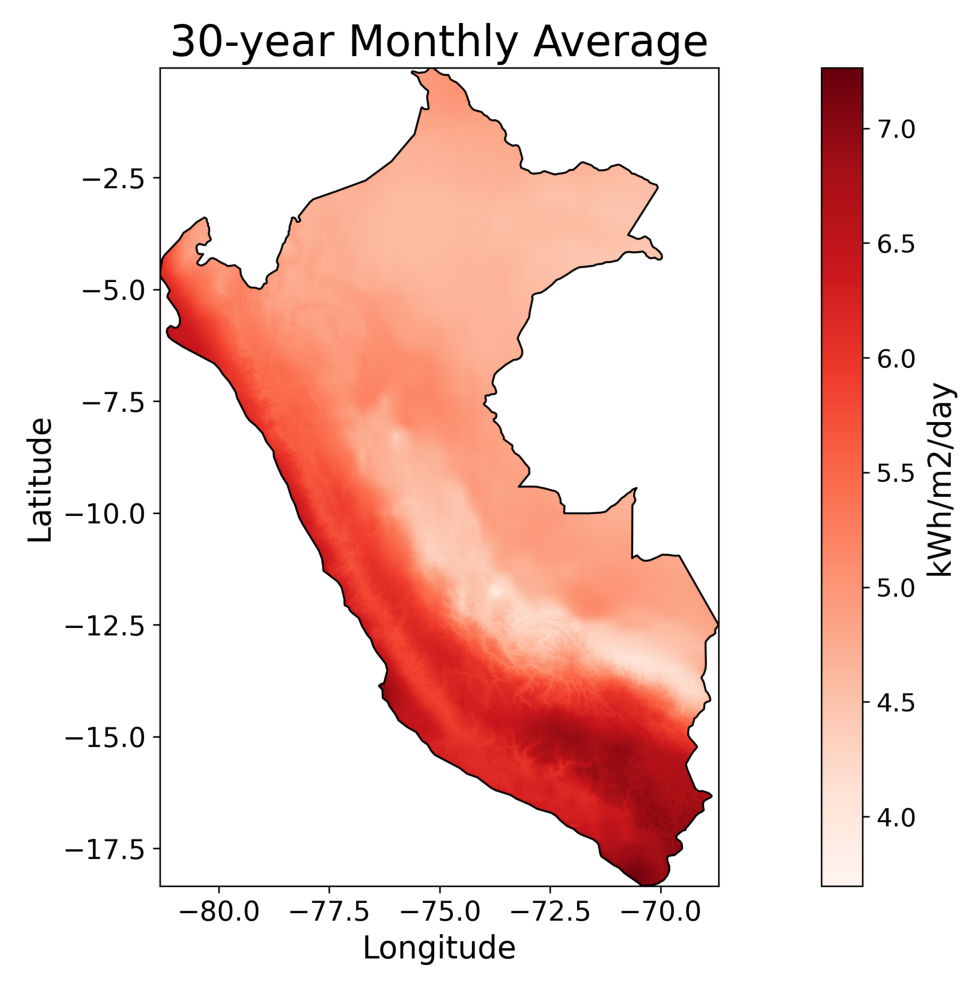

In [21]:
if ATLAS_DEMO != 'hydropower':
    #downscaled_ds = xr.open_dataset(f'./data/downscaled_data/{VAR}/{country}/*_m1*')
    
    #plot_xarray_with_shp(
    #    da=downscaled_ds[f'{VAR}_downscaled'],shp=geometries,cmap=cmap,title="30-year Monthly Average",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/downscaling_{ATLAS_DEMO}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,)
    DOWNSCALING = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/downscaling_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(DOWNSCALING)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    #dis24_aggregated_l5 = gpd.read_file('./data/downscaled_data/{VAR}/{country}/river_discharge_l5_ecuador_m1.geojson')
    #plot_geometries_by_column(
    #    gdf=dis24_aggregated_l5,column="mean_river_discharge",shp=geometries,title="Monthly Climatology",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge.png",figsize=(9, 8),cmap=cmap,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5))
    DIS24_l5 = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(DIS24_l5)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    #dis24_aggregated_l12 = pd.read_csv('./data/downscaled_data/{VAR}/{country}/river_discharge_l12_ecuador_m1.csv')
    #if "Unnamed: 0" in dis24_aggregated_l12.columns:
    #    dis24_aggregated_l12 = dis24_aggregated_l12.drop(columns="Unnamed: 0")
    #dis24_aggregated_l12["geometry"] = gpd.GeoSeries.from_wkt(dis24_aggregated_l12["geometry"])
    #dis24_aggregated_l12 = gpd.GeoDataFrame(dis24_aggregated_l12, geometry="geometry", crs="EPSG:4326")
    #plot_geometries_by_column(
    #    gdf=dis24_aggregated_l12,column="mean_river_discharge",shp=geometries,title="Monthly Climatology",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge_l12.png",figsize=(9, 8),cmap=cmap,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5))
    DIS24_l12 = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge_l12.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(DIS24_l12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Stations 

#### Preprocess of stations data
- removal of the stations with high NaN-percentage
- outlier detection and removal
- Monthly resample and average on the available time series

#### Solar & Wind: Inverse Distance Weighting
- input: dataset of scattered point (stations - known values)
- output: 90m dataset
- method: assign value at unknown grid points assigning a weight based on the distance to the closest stations

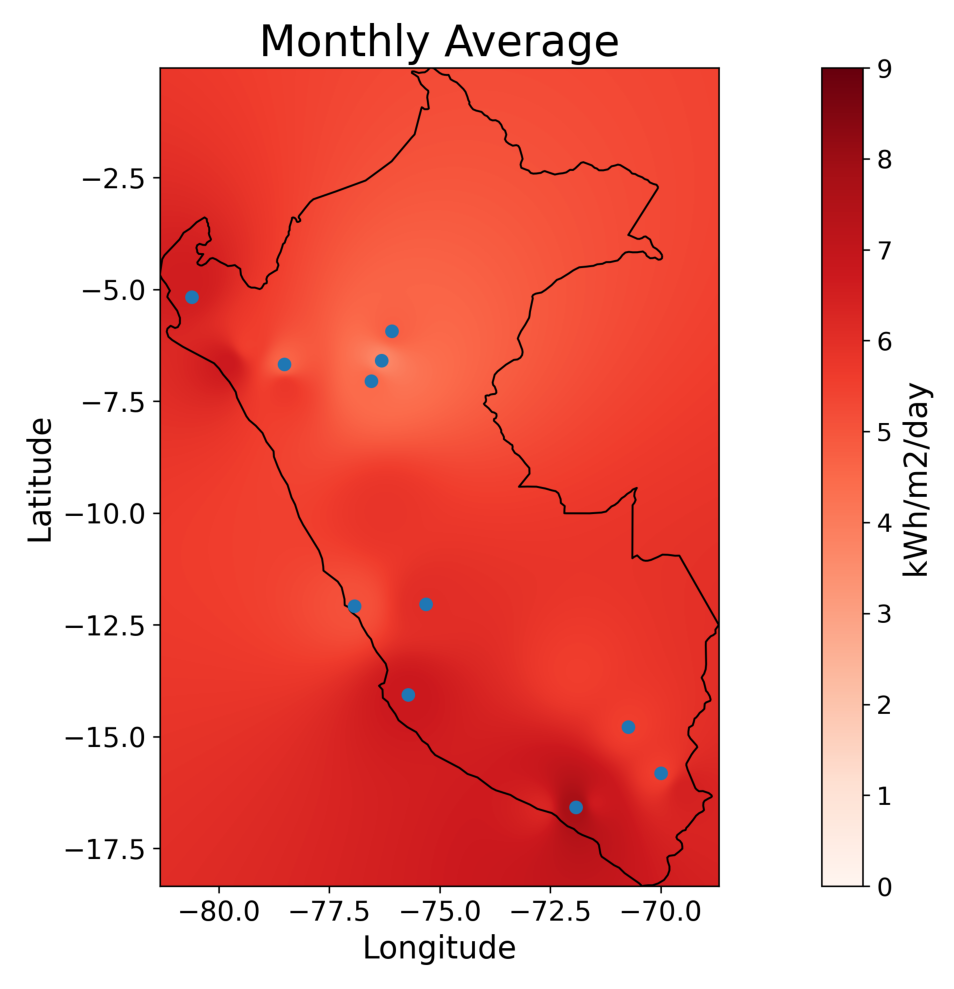

In [22]:
if ATLAS_DEMO == 'wind':
    #stats = pd.read_excel('.data/stations/chile/Metadata_stations.xlsx')
    #ds_idw = xr.open_dataset('.data/stations/chile/idw/u_idw_chile_m1_continental.nc')
    #plot_xarray_with_shp(
    #    da=ds_idw[f'u_reshaped'],shp=geometries,cmap=cmap, title="Monthly Average", cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/idw_{ATLAS_DEMO}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=True)
    IDW = mpimg.imread("./figures/DEMO/wind/idw_wind.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(IDW)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
elif ATLAS_DEMO == 'solar':
    #stats = pd.read_excel('.data/stations/peru/stations_info.xlsx')
    #ds_idw = xr.open_dataset('.data/stations/peru/idw/ssrd_idw_peru_m1.nc')
    #plot_xarray_with_shp(
    #    da=ds_idw.ssrd_reshaped,shp=geometries,cmap="Reds",vmin=0, vmax=9, title="Monthly Average", cbar_label="kWh/m2/day",
    #    output_path="./figures/DEMO/solar/idw_solar.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=True)
    IDW = mpimg.imread("./figures/DEMO/solar/idw_solar.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(IDW)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No IDW performed for this NRA')

#### Hydropower:
- Correct the Level12 subbasins that contain a station with the monthly average there
- The aggregate on Level5 catchments

In [23]:
if ATLAS_DEMO == 'hydropower':
    #shp_basins_l12 = gpd.read_file('./hydrobasins/hybas_lake_sa_lev12_v1c.shp')
    #country_l12_basins = gpd.clip(shp_basins_l12[shp_basins_l12.LAKE == 0], geometries.geometry)

    #stats = pd.read_csv('.data/stations/ecuador/allstats_river_discharge_ecuador.csv')
    
    #plot_geometries_with_shp(
    #    gdf=country_l12_basins,shp=geometries,title="River basins Level 12",output_path="./figures/DEMO/hydropower/river_basins_l12.png",figsize=(9, 8),
    #    facecolor="steelblue",edgecolor="white",linewidth=0.15,shp_edgecolor="black",shp_linewidth=1.2,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5),
    #    title_fontsize=20,label_fontsize=15,tick_fontsize=13,stations=True)

    BASINS_l12 = mpimg.imread("./figures/DEMO/hydropower/river_basins_l12.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(BASINS_l12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print('No HydroBASIN data sets are involved in this NRA')

No HydroBASIN data sets are involved in this NRA


### Integration of station data with reanalysis products

#### Solar and Wind:

- Merge Reanalysis downscaling with IDW gridded data set through this formula. Sigma are uncertainties, for the IDW they depend on the distance to the closest station

$$
\Huge
ssrd_\mathrm{integrated} = \frac{\frac{\mathrm{ssrd}_{\mathrm{era5}}}{\sigma_{\mathrm{era5}}^2} + \frac{\mathrm{ssrd}_{\mathrm{idw}}}{\sigma_{\mathrm{idw}}^2}}{\frac{1}{\sigma_{\mathrm{era5}}^2} + \frac{1}{\sigma_{\mathrm{idw}}^2}}
$$

#### Hydropower
- Level 12-Subbasins river discharge data set corrected at stations locations with a weighted mean. 0.4 for stations, 0.6 for GloFAS
$$Q_{integrated} = w \cdot Q_{station} + (1 - w) \cdot Q_{basin}$$

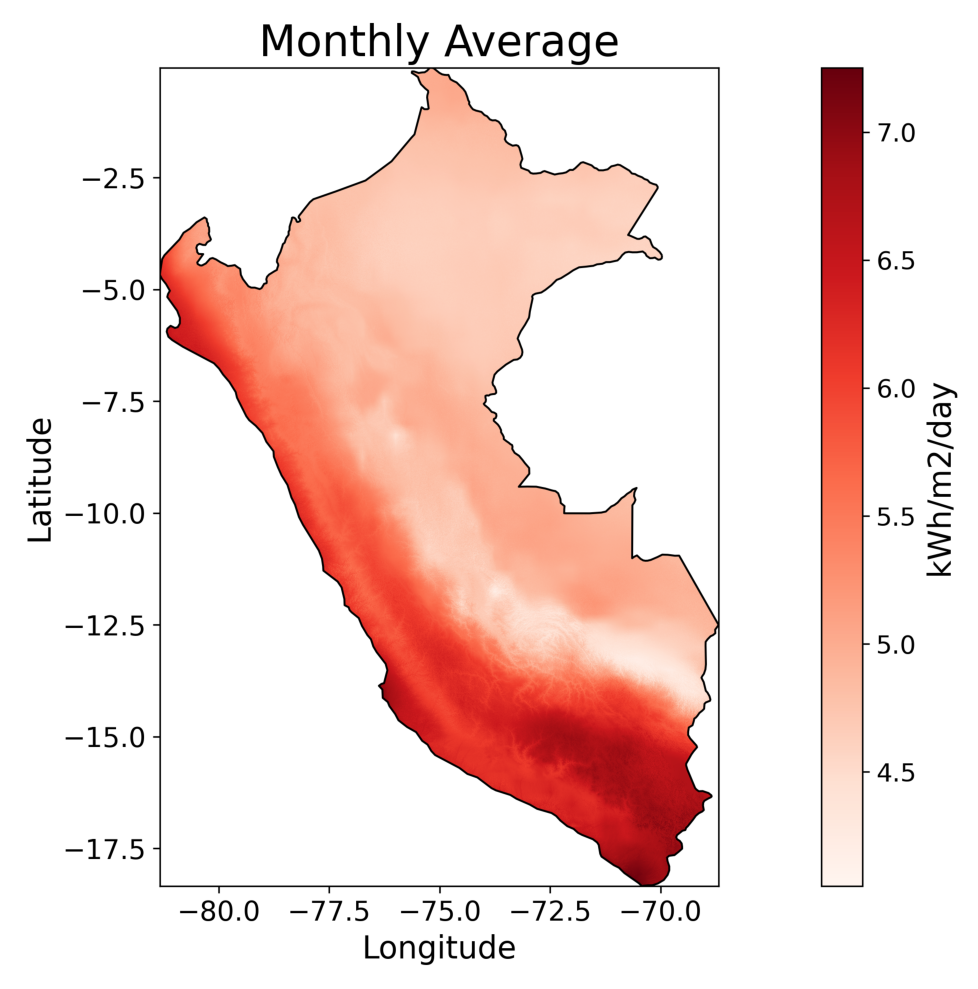

In [24]:
if ATLAS_DEMO =='wind':
    #integrated_data = xr.open_mfdataset(f'./data/atlas_data/{country}/*_integrated_{country}_m1_continental.nc')
    #plot_xarray_with_shp(
    #    da=integrated_data[f'{VAR}_integrated'],shp=geometries,cmap=cmap,title="Monthly Average",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/integrated_{ATLAS_DEMO}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    SCALING = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/integrated_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(SCALING)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
elif ATLAS_DEMO =='solar':
    #integrated_data = xr.open_mfdataset(f'./data/atlas_data/{country}/*_integrated_{country}_m1.nc')
    #plot_xarray_with_shp(
    #    da=integrated_data[f'{VAR}_integrated'],shp=geometries,cmap=cmap,title="Monthly Average",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/integrated_{ATLAS_DEMO}.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    SCALING = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/integrated_{ATLAS_DEMO}.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(SCALING)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    #integrated_data = pd.read_csv('./data/atlas_data/ecuador/river_discharge_l12_ecuador_m1_integrated.csv')
    #if "Unnamed: 0" in integrated_data.columns:
    #    integrated_data = integrated_data.drop(columns="Unnamed: 0")
    #integrated_data["geometry"] = gpd.GeoSeries.from_wkt(integrated_data["geometry"])
    #integrated_data = gpd.GeoDataFrame(integrated_data, geometry="geometry", crs="EPSG:4326")
    #plot_geometries_by_column(
    #    gdf=integrated_data,column="mean_river_discharge_integrated",shp=geometries,title="Monthly Climatology",cbar_label=unit_final,
    #    output_path=f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge_l12_integrated.png",figsize=(9, 8),cmap=cmap,limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5))
    SCALING = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge_l12_integrated.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(SCALING)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Future Climate
- 2 SSP: high criticality and very high criticality
- 1 model output
- 2 climatologies: 2020-2050, 2070-2100

### Download CMIP6

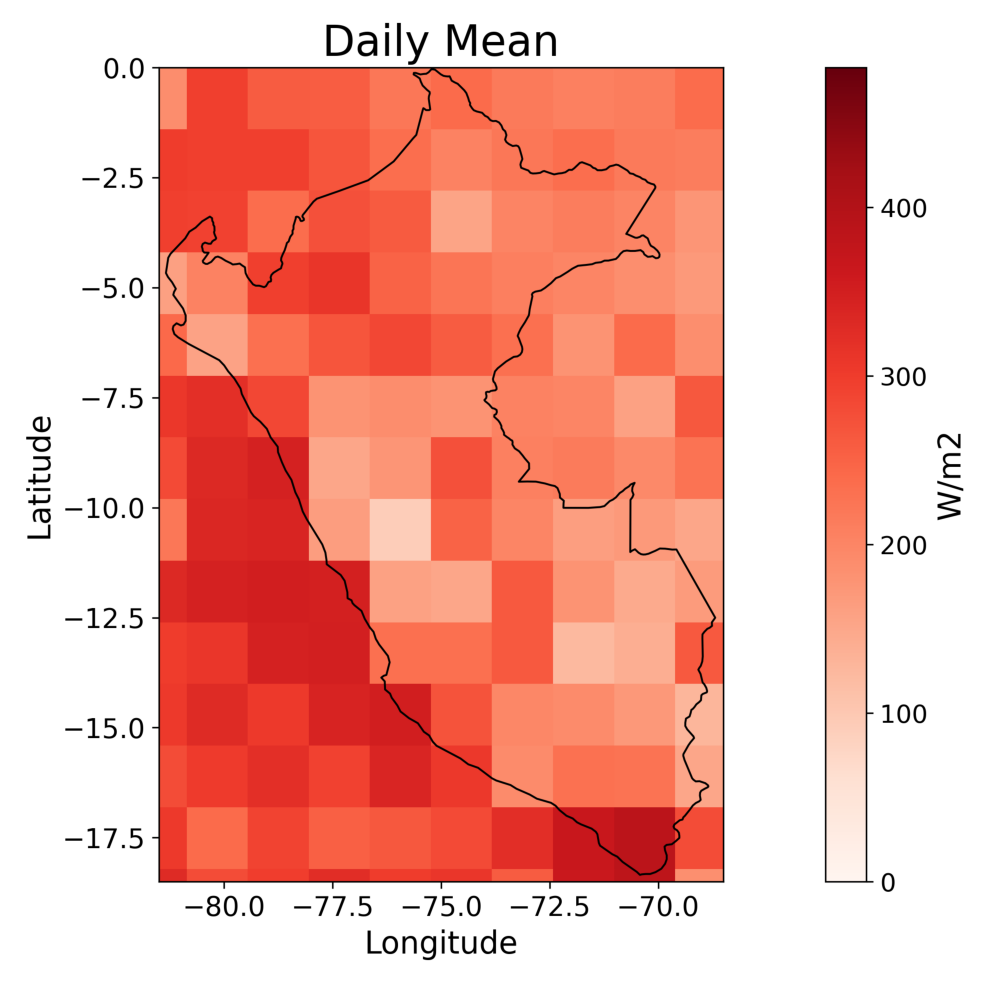

In [25]:
if ATLAS_DEMO == 'hydropower':
    #cmip = xr.open_mfdataset('/mnt/DATA/ARCHIVIO/03_SCENARIOS/03_CMIP6/rivo/global/ssp585/CNRM-ESM2-1/*.nc')
    #cmip = roll_xdf(cmip, lon_name="lon")
    #plot_example_with_shp(
    #    da=cmip.rename({'lat':'latitude','lon':'longitude'}).rivo[0,:,:],shp=geometries, cmap="YlGnBu",vmin=0,vmax=5000,title="Daily Mean",cbar_label="m3/s",
    #    output_path="./figures/DEMO/hydro/cmip_rivo.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,
    #    limits=True,xlim =[-95,-70],ylim =[-7,2] )
    CMIP6_raw = mpimg.imread("./figures/DEMO/hydropower/cmip_rivo.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(CMIP6_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
elif ATLAS_DEMO == 'wind':
    #cmip = xr.open_mfdataset('/mnt/DATA/ARCHIVIO/03_SCENARIOS/03_CMIP6/10m_u_component_of_wind/global/ssp585/CNRM-ESM2-1/*.nc')
    #cmip = roll_xdf(cmip, lon_name="lon")
    #plot_example_with_shp(
    #    da=cmip.rename({'lat':'latitude','lon':'longitude'}).uas[0,0,0,:,:],shp=geometries,cmap="PiYG", title="Daily Mean",cbar_label="m/s",
    #    output_path="./figures/DEMO/wind/cmip_wind.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,
    #    cbar_tick_fontsize=13,
    #    limits=True,
    #    xlim =[-106,-68],
    #    ylim =[-56,-18]
    #)
    CMIP6_raw = mpimg.imread("./figures/DEMO/wind/cmip_wind.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(CMIP6_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    #cmip = xr.open_mfdataset('/mnt/DATA/ARCHIVIO/03_SCENARIOS/03_CMIP6/rsds/global/ssp585/CNRM-ESM2-1/*.nc')
    #cmip = roll_xdf(cmip, lon_name="lon")
    #plot_example_with_shp(
    #    da=cmip.rename({'lat':'latitude','lon':'longitude'}).rsds[0,0,0,:,:],shp=geometries,cmap="Reds", title="Daily Mean",cbar_label="W/m2",
    #    output_path="./figures/DEMO/solar/cmip_solar.png",title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,
    #    cbar_tick_fontsize=13,
    #    limits=True,
    #    xlim =[-82,-69],
    #    ylim =[-18,-0]
    #)
    CMIP6_raw = mpimg.imread("./figures/DEMO/solar/cmip_solar.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(CMIP6_raw)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Delta (SSP - historical)

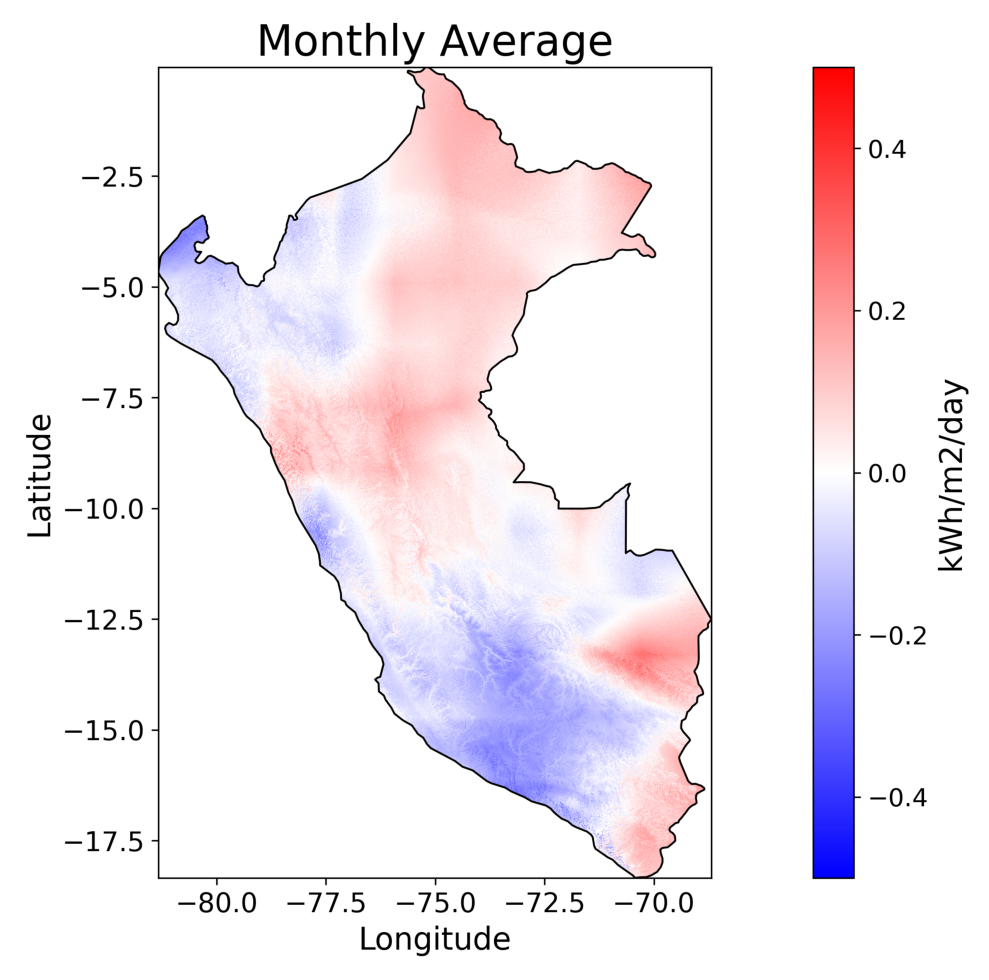

In [26]:
if ATLAS_DEMO == 'wind':
    #wind_future = xr.open_mfdataset('/mnt/DATA/PROGETTI/27_WMO_ATLAS/ATLAS/chile/scaling/ssp585/CNRM-ESM2-1/*_m1_ssp585_continental_2020_2050.nc')
    #plot_xarray_with_shp(
    #    da=wind_future.delta_u10,shp=geometries,cmap="bwr",vmin=-1,vmax=1,title="Monthly Average",cbar_label="m/s",
    #    output_path="./figures/DEMO/wind/delta_wind.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    WIND_DELTA = mpimg.imread("./figures/DEMO/wind/delta_wind.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(WIND_DELTA)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
elif ATLAS_DEMO == 'solar':
    #solar_future = xr.open_dataset('/mnt/DATA/PROGETTI/27_WMO_ATLAS/ATLAS/peru/scaling/ssp585/CNRM-ESM2-1/ssrd_corrected_peru_m1_ssp585_2020_2050.nc')
    #plot_xarray_with_shp(
    #    da=solar_future.delta,shp=geometries,cmap="bwr",vmin=-0.5,vmax=0.5,title="Monthly Average",cbar_label="kWh/m2/day",
    #    output_path="./figures/DEMO/solar/delta_solar.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    SOLAR_DELTA = mpimg.imread("./figures/DEMO/solar/delta_solar.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(SOLAR_DELTA)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    # hydro_future = gpd.read_file('/mnt/DATA/PROGETTI/27_WMO_ATLAS/ATLAS/ecuador/scaling/ssp585/CNRM-ESM2-1/river_discharge_l5_ecuador_m1_ssp585_2020_2050.geojson')
    # plot_geometries_by_column(
    #     gdf=hydro_future,column="delta_river_discharge",shp=geometries,title="Monthly Climatology",cbar_label=unit_final, log_scale=False,
    #     output_path=f"./figures/DEMO/{ATLAS_DEMO}/mean_delta_l5.png",figsize=(9, 8),cmap='viridis',limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5))
    HYDRO_DELTA = mpimg.imread(f"./figures/DEMO/{ATLAS_DEMO}/mean_delta_l5.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(HYDRO_DELTA)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Application of climate-change delta to present-climate products

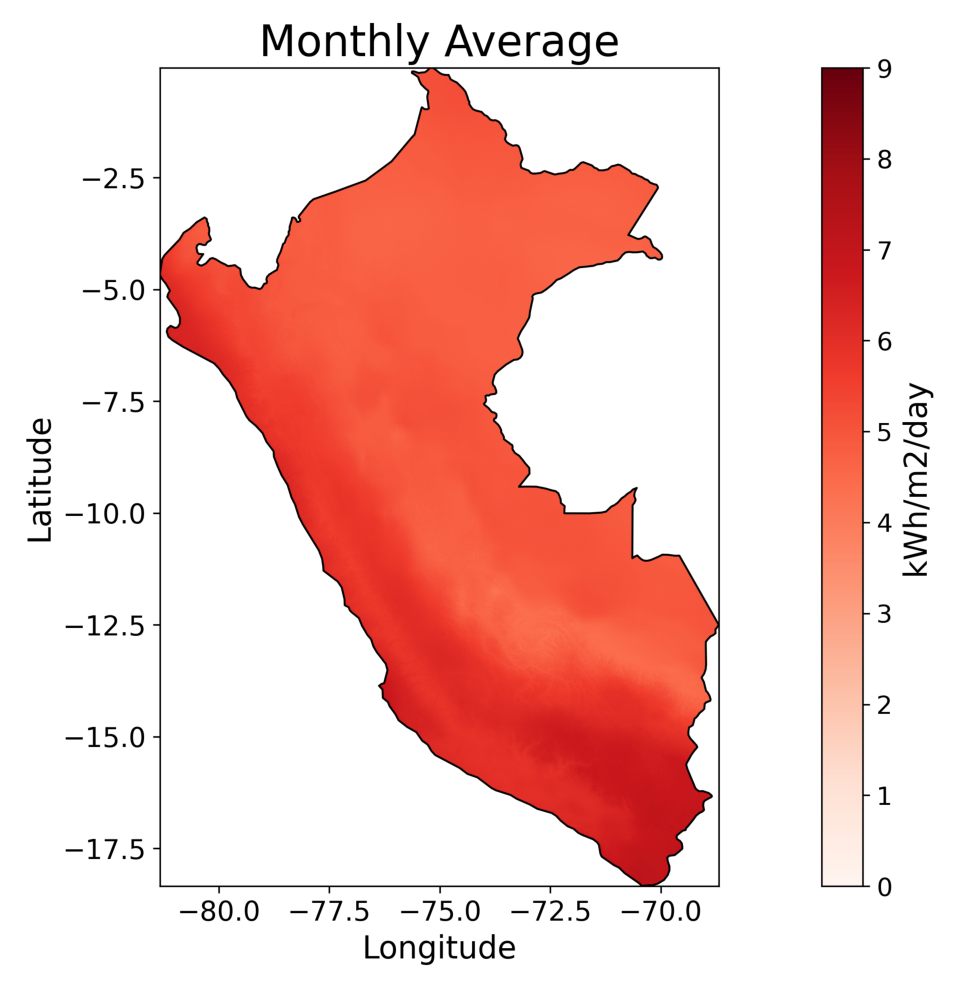

In [27]:
if ATLAS_DEMO == 'wind':
    #wind_future = xr.open_mfdataset('/mnt/DATA/PROGETTI/27_WMO_ATLAS/ATLAS/chile/scaling/ssp585/CNRM-ESM2-1/*_m1_ssp585_continental_2020_2050.nc')
    #plot_xarray_with_shp(
    #    da=wind_future.u10_corrected,shp=geometries,cmap="PiYG",title="Monthly Average",cbar_label="m/s",
    #    output_path="./figures/DEMO/wind/future_wind.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    WIND_FUTURE = mpimg.imread("./figures/DEMO/wind/future_wind.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(WIND_FUTURE)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
elif ATLAS_DEMO == 'solar':
    #plot_xarray_with_shp(
    #    da=solar_future.ssrd_corrected,shp=geometries,cmap="Reds",vmin=0,vmax=9,title="Monthly Average",cbar_label="kWh/m2/day",
    #    output_path="./figures/DEMO/solar//future_solar.png",
    #    title_fontsize=22,label_fontsize=16,tick_fontsize=14,cbar_label_fontsize=16,cbar_tick_fontsize=13,stations=False)
    SOLAR_FUTURE = mpimg.imread("./figures/DEMO/solar/future_solar.png")
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(SOLAR_FUTURE)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    hydro_future = pd.read_csv('/mnt/DATA/PROGETTI/27_WMO_ATLAS/ATLAS/ecuador/scaling/ssp585/CNRM-ESM2-1/river_discharge_l12_ecuador_m1_ssp585_2020_2050.csv')
    if "Unnamed: 0" in hydro_future.columns:
        hydro_future = hydro_future.drop(columns="Unnamed: 0")
    hydro_future["geometry"] = gpd.GeoSeries.from_wkt(hydro_future["geometry"])
    hydro_future = gpd.GeoDataFrame(hydro_future, geometry="geometry", crs="EPSG:4326")
    
    plot_geometries_by_column(
        gdf=hydro_future,column="mean_river_discharge_corrected",shp=geometries,title="Monthly Climatology",cbar_label=unit_final, log_scale =True,
        output_path=f"./figures/DEMO/{ATLAS_DEMO}/mean_river_discharge_future_l12.png",figsize=(9, 8),cmap='Blues',limits=True,xlim=(-92.5, -74.5),ylim=(-5.5, 1.5))

## Key messages for policy makers

This demonstration illustrates how the Atlas methodology upgrades raw climate and environmental datasets into clearer information layers for decision-making.

The workflow highlights three key elements: transparent data provenance, reproducible processing steps, and country-specific products that can support energy planning, infrastructure assessment and climate adaptation strategies.

The visual examples shown here are placeholders for communication and validation. Final Atlas figures should be produced after technical quality control, stakeholder review and harmonisation of cartographic styles.